MODEL 2 — PROPHET SEASONAL PRICE MODEL

Dataset shape: (54340, 28)

Commodities:
['Onion', 'Potato', 'Rice', 'Tomato', 'Wheat']

Onion
Rows: 1088
Date range: 2023-01-01 00:00:00 to 2025-12-31 00:00:00
Missing values: 0

Potato
Rows: 1086
Date range: 2023-01-01 00:00:00 to 2025-12-31 00:00:00
Missing values: 0

Rice
Rows: 1079
Date range: 2023-01-01 00:00:00 to 2025-12-31 00:00:00
Missing values: 0

Tomato
Rows: 1086
Date range: 2023-01-01 00:00:00 to 2025-12-31 00:00:00
Missing values: 0

Wheat
Rows: 1090
Date range: 2023-01-01 00:00:00 to 2025-12-31 00:00:00
Missing values: 0

Training Prophet: Onion


09:27:52 - cmdstanpy - INFO - Chain [1] start processing
09:27:52 - cmdstanpy - INFO - Chain [1] done processing
09:27:52 - cmdstanpy - INFO - Chain [1] start processing


Onion model trained successfully.

Training Prophet: Potato


09:27:53 - cmdstanpy - INFO - Chain [1] done processing
09:27:53 - cmdstanpy - INFO - Chain [1] start processing


Potato model trained successfully.

Training Prophet: Rice


...

Rice model trained successfully.

Training Prophet: Tomato


09:27:53 - cmdstanpy - INFO - Chain [1] done processing
09:27:53 - cmdstanpy - INFO - Chain [1] start processing


Tomato model trained successfully.

Training Prophet: Wheat


09:27:54 - cmdstanpy - INFO - Chain [1] done processing


Wheat model trained successfully.

GENERATING 30-DAY FORECAST

Onion
        ds       yhat  yhat_lower  yhat_upper
2026-01-01 769.601667  615.090471  975.063041
2026-01-02 755.100820  606.797943  956.321302
2026-01-03 739.730340  599.146189  931.448594
2026-01-04 755.447394  597.762606  945.482179
2026-01-05 735.934234  597.572775  916.757473
2026-01-06 735.944830  588.302795  910.947556
2026-01-07 725.189269  580.153415  924.174398
2026-01-08 707.764445  571.798526  881.884762
2026-01-09 695.958441  550.187711  886.874045
2026-01-10 682.602817  544.584223  855.844058
2026-01-11 697.248919  548.465303  870.808266
2026-01-12 678.740310  543.621629  855.598084
2026-01-13 677.677340  540.634610  866.845733
2026-01-14 666.223806  521.008408  820.186523
2026-01-15 648.312979  519.520882  831.695228
2026-01-16 635.344915  508.034583  814.311763
2026-01-17 620.867899  496.403538  783.933980
2026-01-18 631.796428  498.136451  798.157292
2026-01-19 612.739902  488.014064  763.727317
2026-01-20 

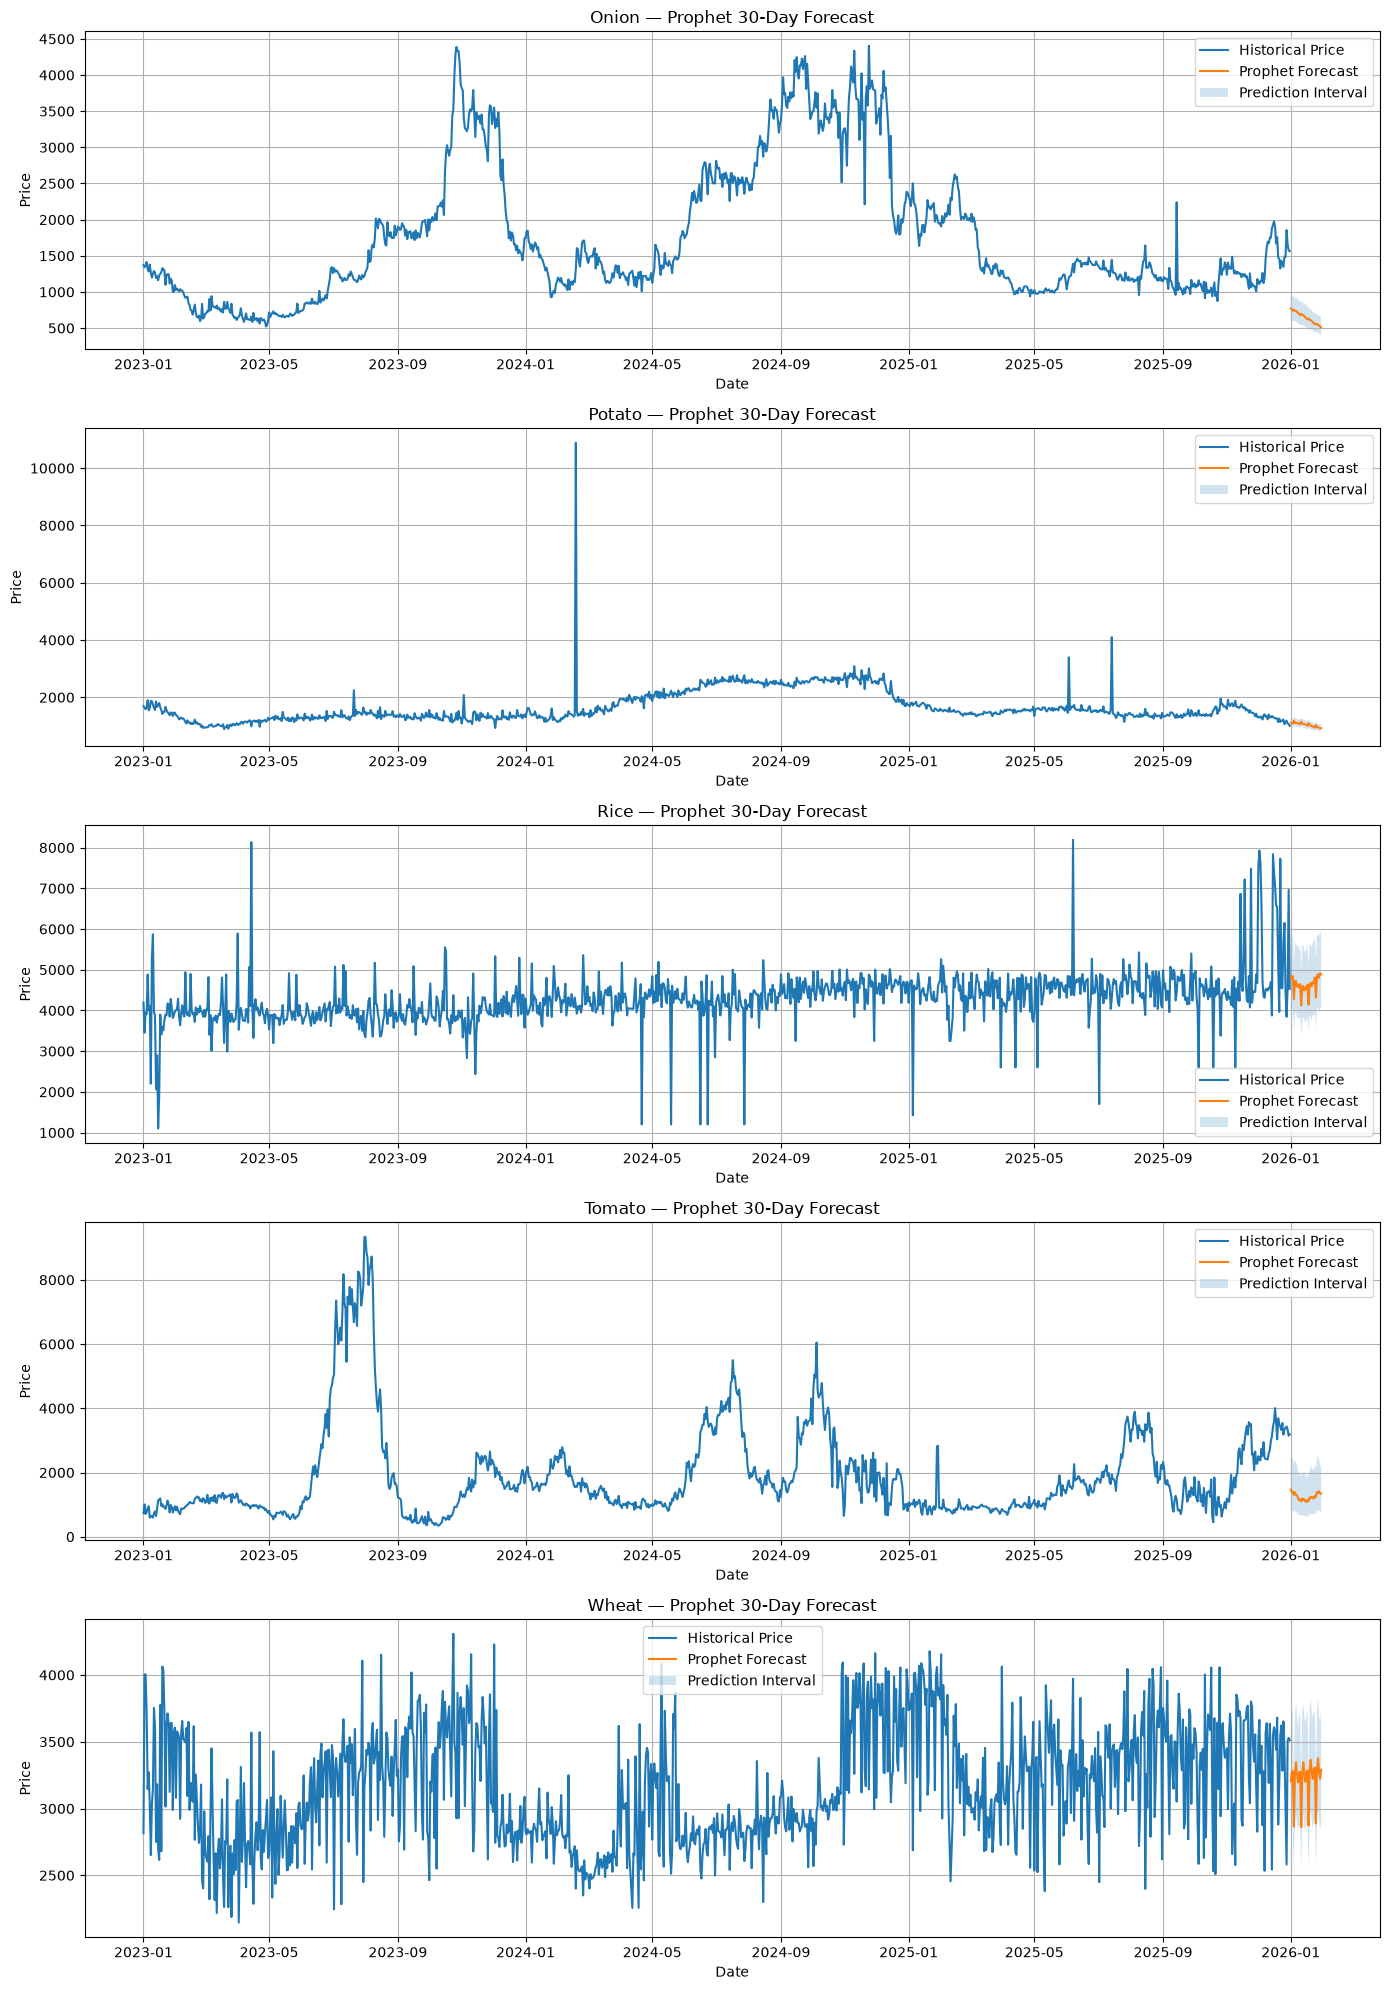


MODEL 2 COMPLETED

Forecasts generated for:
✓ Onion
✓ Potato
✓ Rice
✓ Tomato
✓ Wheat


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ==============================================================
# MODEL 2 — PROPHET SEASONAL PRICE MODEL
# ==============================================================

print("=" * 70)
print("MODEL 2 — PROPHET SEASONAL PRICE MODEL")
print("=" * 70)


# ==============================================================
# STEP 1 — LOAD DATA
# ==============================================================

df = pd.read_csv("../data/raw/final_dataset.csv")

df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

df["Modal_Price"] = pd.to_numeric(
    df["Modal_Price"],
    errors="coerce"
)

df = df.dropna(
    subset=[
        "Date",
        "Modal_Price",
        "Commodity"
    ]
)

print("\nDataset shape:", df.shape)


# ==============================================================
# STEP 2 — COMMODITIES
# ==============================================================

commodities = [
    "Onion",
    "Potato",
    "Rice",
    "Tomato",
    "Wheat"
]

print("\nCommodities:")
print(commodities)


# ==============================================================
# STEP 3 — PREPARE DAILY DATA
# ==============================================================

prophet_data = {}

for commodity in commodities:

    data = df[
        df["Commodity"] == commodity
    ][
        ["Date", "Modal_Price"]
    ].copy()

    # Sort by date
    data = data.sort_values("Date")

    # Average all market observations for each date
    data = (
        data
        .groupby("Date")["Modal_Price"]
        .mean()
        .reset_index()
    )

    # Keep only positive prices
    data = data[
        data["Modal_Price"] > 0
    ].copy()

    # Prophet format
    data = data.rename(
        columns={
            "Date": "ds",
            "Modal_Price": "y"
        }
    )

    # IMPORTANT:
    # Store ORIGINAL price separately
    data["y_original"] = data["y"]

    # Log transformation
    data["y"] = np.log1p(
        data["y"]
    )

    # Save commodity data
    prophet_data[commodity] = data

    print("\n" + "=" * 70)
    print(commodity)
    print("=" * 70)

    print("Rows:", len(data))

    print(
        "Date range:",
        data["ds"].min(),
        "to",
        data["ds"].max()
    )

    print(
        "Missing values:",
        data[["ds", "y"]]
        .isnull()
        .sum()
        .sum()
    )


# ==============================================================
# STEP 4 — TRAIN PROPHET MODELS
# ==============================================================

prophet_models = {}

for commodity in commodities:

    print("\n" + "=" * 70)
    print("Training Prophet:", commodity)
    print("=" * 70)

    data = prophet_data[commodity][
        ["ds", "y"]
    ].copy()

    model = Prophet(
        growth="linear",
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,

        # Controls how strongly trend can change
        changepoint_prior_scale=0.01,

        # Controls seasonal strength
        seasonality_prior_scale=1.0
    )

    model.fit(data)

    prophet_models[commodity] = model

    print(
        commodity,
        "model trained successfully."
    )


# ==============================================================
# STEP 5 — 30-DAY FORECAST
# ==============================================================

print("\n" + "=" * 70)
print("GENERATING 30-DAY FORECAST")
print("=" * 70)

forecasts = {}

for commodity in commodities:

    print("\n" + "=" * 70)
    print(commodity)
    print("=" * 70)

    model = prophet_models[commodity]

    data = prophet_data[commodity]

    # Last historical date
    last_date = data["ds"].max()

    # Create exactly 30 future days
    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=30,
        freq="D"
    )

    future = pd.DataFrame({
        "ds": future_dates
    })

    # Predict
    forecast = model.predict(
        future
    )

    # Convert log prediction back to price
    forecast["yhat"] = np.expm1(
        forecast["yhat"]
    )

    forecast["yhat_lower"] = np.expm1(
        forecast["yhat_lower"]
    )

    forecast["yhat_upper"] = np.expm1(
        forecast["yhat_upper"]
    )

    # Safety check against infinity
    forecast[
        ["yhat", "yhat_lower", "yhat_upper"]
    ] = forecast[
        ["yhat", "yhat_lower", "yhat_upper"]
    ].replace(
        [np.inf, -np.inf],
        np.nan
    )

    # Remove impossible negative values
    forecast["yhat"] = forecast["yhat"].clip(
        lower=0
    )

    forecast["yhat_lower"] = forecast[
        "yhat_lower"
    ].clip(
        lower=0
    )

    forecast["yhat_upper"] = forecast[
        "yhat_upper"
    ].clip(
        lower=0
    )

    forecasts[commodity] = forecast

    print(
        forecast[
            [
                "ds",
                "yhat",
                "yhat_lower",
                "yhat_upper"
            ]
        ].to_string(index=False)
    )


# ==============================================================
# STEP 6 — SEASONAL COMPONENT ANALYSIS
# ==============================================================

print("\n" + "=" * 70)
print("SEASONAL COMPONENT ANALYSIS")
print("=" * 70)

seasonal_results = {}

for commodity in commodities:

    model = prophet_models[commodity]

    data = prophet_data[commodity][
        ["ds", "y"]
    ].copy()

    # Predict historical data
    historical_forecast = model.predict(
        data
    )

    seasonal_results[commodity] = (
        historical_forecast
    )

    print("\n" + "=" * 70)
    print(commodity)
    print("=" * 70)

    print(
        "Yearly seasonality available:",
        "yearly" in historical_forecast.columns
    )

    print(
        "Weekly seasonality available:",
        "weekly" in historical_forecast.columns
    )


# ==============================================================
# STEP 7 — PLOT 30-DAY FORECASTS
# ==============================================================

fig, axes = plt.subplots(
    5,
    1,
    figsize=(14, 20)
)

for i, commodity in enumerate(
    commodities
):

    data = prophet_data[commodity]

    forecast = forecasts[commodity]

    # Historical original price
    historical_price = (
        data["y_original"]
    )

    axes[i].plot(
        data["ds"],
        historical_price,
        label="Historical Price"
    )

    axes[i].plot(
        forecast["ds"],
        forecast["yhat"],
        label="Prophet Forecast"
    )

    axes[i].fill_between(
        forecast["ds"],
        forecast["yhat_lower"],
        forecast["yhat_upper"],
        alpha=0.2,
        label="Prediction Interval"
    )

    axes[i].set_title(
        f"{commodity} — Prophet 30-Day Forecast"
    )

    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Price")

    axes[i].legend()
    axes[i].grid(True)


plt.tight_layout()

plt.savefig(
    "prophet_30_day_forecasts.png",
    dpi=300
)

plt.show()


print("\n" + "=" * 70)
print("MODEL 2 COMPLETED")
print("=" * 70)

print(
    "\nForecasts generated for:"
)

for commodity in commodities:
    print(
        f"✓ {commodity}"
    )

In [18]:
# ==============================================================
# STEP 8 — PROPHET MODEL EVALUATION
# ==============================================================

print("\n" + "=" * 70)
print("PROPHET MODEL PERFORMANCE")
print("=" * 70)

evaluation_results = {}

for commodity in commodities:

    data = prophet_data[commodity].copy()

    model = prophet_models[commodity]

    # Predict historical observations
    historical = model.predict(
        data[["ds"]]
    )

    # Convert Prophet log prediction back to original price
    actual_price = data["y_original"].values

    predicted_price = np.expm1(
        historical["yhat"].values
    )

    # Safety
    predicted_price = np.maximum(
        predicted_price,
        0
    )

    # Metrics
    mae = mean_absolute_error(
        actual_price,
        predicted_price
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual_price,
            predicted_price
        )
    )

    r2 = r2_score(
        actual_price,
        predicted_price
    )

    evaluation_results[commodity] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

    print("\n" + "=" * 60)
    print(commodity)
    print("=" * 60)

    print(f"MAE  : ₹{mae:.2f}")
    print(f"RMSE : ₹{rmse:.2f}")
    print(f"R²   : {r2:.4f}")


# ==============================================================
# STEP 9 — PERFORMANCE TABLE
# ==============================================================

performance_df = pd.DataFrame(
    evaluation_results
).T

performance_df = performance_df.reset_index()

performance_df = performance_df.rename(
    columns={
        "index": "Commodity"
    }
)

print("\n" + "=" * 70)
print("PROPHET MODEL PERFORMANCE TABLE")
print("=" * 70)

print(
    performance_df.to_string(
        index=False
    )
)


PROPHET MODEL PERFORMANCE

Onion
MAE  : ₹236.96
RMSE : ₹359.63
R²   : 0.8487

Potato
MAE  : ₹100.59
RMSE : ₹323.34
R²   : 0.6747

Rice
MAE  : ₹344.70
RMSE : ₹559.55
R²   : 0.2573

Tomato
MAE  : ₹633.13
RMSE : ₹1061.08
R²   : 0.4691

Wheat
MAE  : ₹243.66
RMSE : ₹307.02
R²   : 0.5057

PROPHET MODEL PERFORMANCE TABLE
Commodity        MAE        RMSE       R2
    Onion 236.964815  359.634895 0.848654
   Potato 100.585114  323.344510 0.674691
     Rice 344.703363  559.549946 0.257285
   Tomato 633.130990 1061.078294 0.469066
    Wheat 243.657054  307.022250 0.505699


In [19]:
# ==============================================================
# STEP 10 — TIME-BASED TRAIN / TEST EVALUATION
# 2023-2024 = TRAIN
# 2025 = TEST
# ==============================================================

print("\n" + "=" * 70)
print("PROPHET TIME-BASED TESTING")
print("TRAIN: 2023-2024 | TEST: 2025")
print("=" * 70)

time_test_results = {}

for commodity in commodities:

    print("\n" + "=" * 60)
    print(commodity)
    print("=" * 60)

    data = prophet_data[commodity].copy()

    # ----------------------------------------------------------
    # Training data
    # ----------------------------------------------------------

    train = data[
        data["ds"] < "2025-01-01"
    ].copy()

    # ----------------------------------------------------------
    # Test data
    # ----------------------------------------------------------

    test = data[
        data["ds"] >= "2025-01-01"
    ].copy()

    print("Training rows:", len(train))
    print("Testing rows :", len(test))

    # ----------------------------------------------------------
    # Train new Prophet model
    # ----------------------------------------------------------

    test_model = Prophet(
        growth="linear",
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.01,
        seasonality_prior_scale=1.0
    )

    test_model.fit(
        train[["ds", "y"]]
    )

    # ----------------------------------------------------------
    # Predict test period
    # ----------------------------------------------------------

    test_forecast = test_model.predict(
        test[["ds"]]
    )

    # Convert prediction back to ₹
    predicted = np.expm1(
        test_forecast["yhat"].values
    )

    predicted = np.maximum(
        predicted,
        0
    )

    actual = test["y_original"].values

    # ----------------------------------------------------------
    # Metrics
    # ----------------------------------------------------------

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    time_test_results[commodity] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

    print(f"MAE  : ₹{mae:.2f}")
    print(f"RMSE : ₹{rmse:.2f}")
    print(f"R²   : {r2:.4f}")


# ==============================================================
# FINAL TIME-BASED PERFORMANCE TABLE
# ==============================================================

time_test_df = pd.DataFrame(
    time_test_results
).T.reset_index()

time_test_df = time_test_df.rename(
    columns={
        "index": "Commodity"
    }
)

print("\n" + "=" * 70)
print("PROPHET — FINAL TIME-BASED PERFORMANCE")
print("=" * 70)

print(
    time_test_df.to_string(
        index=False
    )
)


PROPHET TIME-BASED TESTING
TRAIN: 2023-2024 | TEST: 2025

Onion
Training rows: 724
Testing rows : 364


09:30:32 - cmdstanpy - INFO - Chain [1] start processing
09:30:33 - cmdstanpy - INFO - Chain [1] done processing


MAE  : ₹522.62
RMSE : ₹625.97
R²   : -1.5360

Potato
Training rows: 723
Testing rows : 363


09:30:33 - cmdstanpy - INFO - Chain [1] start processing
09:30:34 - cmdstanpy - INFO - Chain [1] done processing


MAE  : ₹1386.02
RMSE : ₹1493.23
R²   : -42.3865

Rice
Training rows: 716
Testing rows : 363


...

MAE  : ₹529.63
RMSE : ₹747.09
R²   : -0.0170

Tomato
Training rows: 724
Testing rows : 362


09:30:37 - cmdstanpy - INFO - Chain [1] start processing
09:30:37 - cmdstanpy - INFO - Chain [1] done processing
09:30:38 - cmdstanpy - INFO - Chain [1] start processing


MAE  : ₹1338.83
RMSE : ₹2081.96
R²   : -4.5086

Wheat
Training rows: 727
Testing rows : 363


09:30:38 - cmdstanpy - INFO - Chain [1] done processing


MAE  : ₹1610.43
RMSE : ₹1898.72
R²   : -22.5017

PROPHET — FINAL TIME-BASED PERFORMANCE
Commodity         MAE        RMSE         R2
    Onion  522.622957  625.966500  -1.535953
   Potato 1386.017354 1493.229967 -42.386499
     Rice  529.625615  747.086356  -0.017041
   Tomato 1338.826667 2081.964548  -4.508558
    Wheat 1610.432074 1898.723815 -22.501717
